<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi

</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 6</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 6</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- Aufgabe 06_01: Sonne und Erde
- **Aufgabe 06_02: Pendel**

In dieser Aufgabe werden Sie erneut das Eulerverfahren und zusätzlich das klassische Runge-Kutta Verfahren implementieren und am Modell eines einfachen mathematisches Pendels vergleichen und analysieren.
Wir wollen allerdings hier versuchen, allgemeine Lösungsfunktionen zu erstellen, die nichts über die DGL oder Ihre Startbedingungen wissen.

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline"> Das mathematische Pendel</td>


Betrachten Sie ein System von verschiedenen Größen $y_i$. $y = (y_1, y_2, ... y_n)^T$ enthält dann alle Größen des Systems, sodass
$$ \frac{dy}{dt} = \begin{pmatrix} \frac{dy_1}{dt} \\ \frac{dy_2}{dt} \\ ... \\ \frac{dy_n}{dt} \end{pmatrix} = f(y,t)$$
ein System von Differentialgleichungen erster Ordnung darstellt.

### a) DGL des Mathematischen Pendels

Die Differentialgleichung des mathematischen Pendels ist

$$\ddot{\varphi}(t) + \frac{g}{l} \cdot \sin \left(\varphi(t) \right) = 0$$

wobei $\varphi$ der Auslenkungswinkel, $l$ die Länge des Pendels und $g$ die Stärke des Gravitationsfeldes auf der Erde ist. Diese DGL ist offensichtlich nicht erster Ornung. Finden Sie eine Substitution, welche diese DGL in ein System von DGL's erster Ordnung umformt und schreiben Sie anschließend eine Funktion, die entsprechend $f(y,t) = \frac{dy}{dt}$ ausgibt.

In [1]:
# Substitution: y1 = phi (Auslenkungswinkel), y2 = phi_dot (Winkelgeschwindigkeit)
# Aus der DGL zweiter Ordnung phi'' + g/l * sin(phi) = 0 wird damit das System erster Ordnung:
#   dy1/dt = y2
#   dy2/dt = -g/l * sin(y1)
#
# Da in f keine explizite Zeitabhaengigkeit auftritt (das Pendel ist ein autonomes System),
# schreiben wir im Folgenden f(y) statt f(y,t).

g = 9.81   # Erdbeschleunigung in m/s^2
l = 1.0    # Pendellaenge in m

function pendel(y)
    y1, y2 = y
    return [y2, -g/l*sin(y1)]
end


pendel (generic function with 1 method)

### b) Allgemeine Eulerintegration

Erstellen Sie eine Funktion ``euler_step``, welche ein System von Differentialgleichungen $f(y,t)$, ein Array der aktuellen Werte $y_t$ und eine Schrittgröße $dt$ übergeben bekommt und anschließend mit Hilfe der Eulerintegration die Werte von y für den nächsten Zeitpunkt bestimmt und zurück gibt.

**Hinweis**: In dieser Schreibweise lässt sich das Eulerverfahren so auffassen:
$$y[t+1] = y[t] + f(y[t]) \cdot dt$$

In [2]:
function euler_step(f, y_t, dt)
    return y_t .+ dt .* f(y_t)
end


euler_step (generic function with 1 method)

**Erklärung:** `euler_step` führt genau einen Zeitschritt der Größe `dt` des Eulerverfahrens aus: $y_{t+1} = y_t + f(y_t)\cdot dt$. Da unser System autonom ist (kein explizites $t$ in $f$), reicht `f(y_t)` aus.

Schreiben Sie nun eine Funktion ``euler_integrator``, welche eine Abbruchzeit $t_{max}$, die Anzahl der Iterationsschritte $n$, das zu intergrierende System an Differentialgleichungen $f$ und ein Array an Startbedingungen $y_0$ übergeben bekommt und dann einen Datensatz von y über den gesamten Zeitraum zurückgibt.

In [3]:
function euler_integrator(t_max, n, f, y_0)
    #Dimension des Problems erfassen:
    d = size(y_0,1)
    dt = t_max/(n-1)
    #Array fuer den Datensatz initialisieren (Zeilen = Zeitschritte, Spalten = Komponenten von y):
    timeseries = Array{Float64}(undef, n, d)
    timeseries[1, :] = y_0

    for i in 2:n
        timeseries[i, :] = euler_step(f, timeseries[i-1, :], dt)
    end

    return timeseries
end


euler_integrator (generic function with 1 method)

Testen Sie Ihre Funktion anschließend mit dem mathematischen Pendel und plotten Sie die Auslenkung des Pendels gegen die Zeit.
Vorgeschlagene Parameter sind vorgegeben, spielen Sie aber ruhig etwas herum :)


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


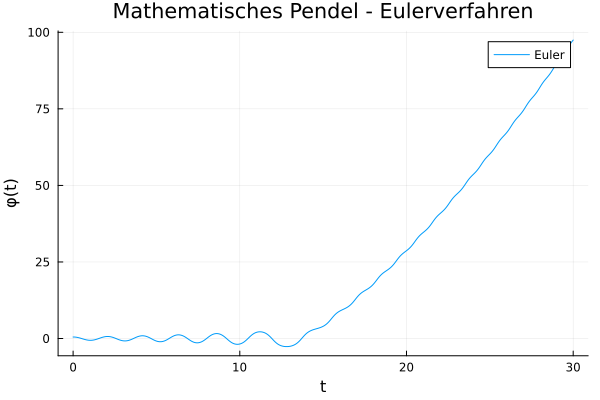

In [4]:
using Plots

t_max = 30
n = 1000
y_0 = [0.5,0]
Zeiten = 0:t_max/(n-1):t_max

Y_euler = euler_integrator(t_max, n, pendel, y_0)

plot(Zeiten, Y_euler[:,1], xlabel="t", ylabel="φ(t)", label="Euler",
     title="Mathematisches Pendel - Eulerverfahren", legend=:topright)


### c) Allgemeine Runge-Kutta Integration

Wiederholen Sie Aufgabenteil b) für das klassische Runge-Kutta Verfahren (vierter Ordnung).

**Hinweis**: Ein Ruge-Kutta Schritt sieht formell so aus:
\begin{align}
k_1 &= f(t_i, y_i)
\\
k_2 &= f(t_i + \frac{dt}{2}, y_i + \frac{dt}{2} k_1)
\\
k_3 &= f(t_i + \frac{dt}{2}, y_i + \frac{dt}{2} k_2)
\\
k_4 &= f(t_i + dt, y_i + dt \cdot k_3)
\\
y_{i+1} &= y_i +dt\cdot {\frac {1}{6}}\left(k_{1}+2k_{2}+2k_{3}+k_{4}\right)
\end{align}

Plotten Sie anschließend die Auslenkung des Pendels für beide Verfahren gegen die Zeit.

In [5]:
function rk4_step(f, y_t, dt)
    k1 = f(y_t)
    k2 = f(y_t .+ dt/2 .* k1)
    k3 = f(y_t .+ dt/2 .* k2)
    k4 = f(y_t .+ dt   .* k3)
    return y_t .+ dt/6 .* (k1 .+ 2 .* k2 .+ 2 .* k3 .+ k4)
end


rk4_step (generic function with 1 method)

**Erklärung:** `rk4_step` berechnet die vier Hilfssteigungen $k_1,\dots,k_4$ und kombiniert sie zu einem gewichteten Mittel, wodurch das Verfahren eine deutlich höhere Genauigkeit (Fehler $\mathcal{O}(dt^5)$ pro Schritt) als das Eulerverfahren (Fehler $\mathcal{O}(dt^2)$ pro Schritt) erreicht.

In [6]:
function rk4_integrator(t_max, n, f, y_0)
    d = size(y_0,1)
    dt = t_max/(n-1)
    timeseries = Array{Float64}(undef, n, d)
    timeseries[1, :] = y_0

    for i in 2:n
        timeseries[i, :] = rk4_step(f, timeseries[i-1, :], dt)
    end

    return timeseries
end


rk4_integrator (generic function with 1 method)

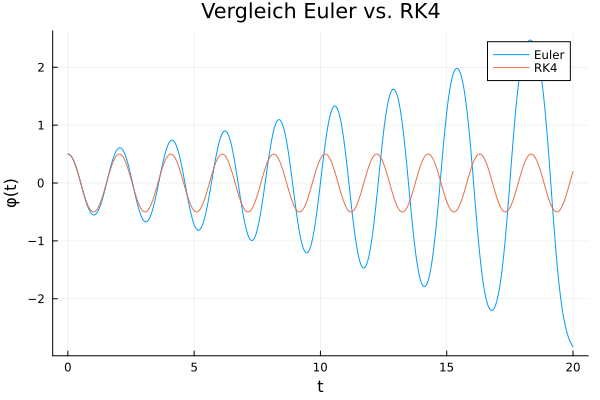

In [7]:
t_max = 20
n = 1000
y_0 = [0.5,0]
Zeiten = 0:t_max/(n-1):t_max

Y_euler = euler_integrator(t_max, n, pendel, y_0)
Y_rk4   = rk4_integrator(t_max, n, pendel, y_0)

plot(Zeiten, Y_euler[:,1], label="Euler")
plot!(Zeiten, Y_rk4[:,1], label="RK4", xlabel="t", ylabel="φ(t)",
      title="Vergleich Euler vs. RK4", legend=:topright)


### d) Konvergenzverhalten des Eulerverfahrens

Wie Ihnen im direkten Vergleich von RK4 und Euler (bei vorgegebenen Parametern) aufgefallen sein sollte, ist die maximale Auslenkung des Pendels im Eulerverfahren nicht konstant, was sie aber sein sollte. Wir wollen nun die Größe dieser Abweichung für verschieden viele Iterationen $n$ analysieren.

Schreiben Sie dazu zunächst eine Funktion, welche die Werte aller lokalen Extrema der Auslenkungen findet.

In [8]:
function finde_extrema(x)
    extrema = Float64[]
    for i in 2:length(x)-1
        if (x[i] > x[i-1] && x[i] > x[i+1]) || (x[i] < x[i-1] && x[i] < x[i+1])
            push!(extrema, x[i])
        end
    end
    return extrema
end


finde_extrema (generic function with 1 method)

**Erklärung:** Ein lokales Extremum an Position `i` liegt vor, wenn der Wert entweder größer ist als beide direkten Nachbarn (lokales Maximum) oder kleiner als beide Nachbarn (lokales Minimum). Für das Pendel entsprechen diese Extrema den Umkehrpunkten der Schwingung, deren Betrag bei exakter Energieerhaltung konstant gleich der Anfangsauslenkung $\varphi_0$ sein sollte.

Um die Größe der Abweichung zu quantifizieren benutzen wir den folgende ($L_2$-)Fehler:

$$\epsilon_{L_2} = \frac{\sqrt{\sum_{j=1}^{N} (x_j - \bar{x})^2}}{N}$$

wobei wir $N$ Werte $x_j$ haben und den Wert $\bar{x}$ als Ergebnis erwarten.

Erstellen Sie nun die Zeitserie für Zeiten in [0,10] mit einer steigenden Anzahl an Unterteilungen $n$ des Zeitintervalls für die numerische Integration.

Starten Sie dafuer jedes mal mit den selben Startbedingungen: eine beliebige Startauslenkung $\varphi_0 \neq 0 \neq \pi$ und eine Winkelgeschwindigkeit $\omega_0 = 0$.

Benutzen Sie dann die `finde_extrema` Funktion um die extremalen Auslenkungen bei einem fixen $n$ zu finden und berechnen Sie dann für jedes $n$ $\epsilon_{L_2}$ und
speichern Sie das Ergebnis in einer Liste. Wiederholen Sie dies fuer die Euler Integration und die Runge-Kutta Integration.

In [9]:
t_max = 10

n_min = 50
n_max = 300 

phi_0 = 1 # Erwarteter Absoluter Maximal Wert
y_0 = [phi_0, 0.0]  # omega_0 = 0

n_values = n_min:n_max
ϵ_values = Array{Float64}(undef, length(n_values))       # Fehler des Eulerverfahrens
ϵ_values_rk4 = Array{Float64}(undef, length(n_values))   # Fehler des RK4-Verfahrens

# enumerate(array) gibt euch ein Paar (j,a) zurueck wobei j der aktuelle Index und a = array[j] ist.

for (j, n) in enumerate(n_values)
    Y_euler = euler_integrator(t_max, n, pendel, y_0)
    Y_rk4   = rk4_integrator(t_max, n, pendel, y_0)

    ext_euler = abs.(finde_extrema(Y_euler[:,1]))
    ext_rk4   = abs.(finde_extrema(Y_rk4[:,1]))

    N_e = length(ext_euler)
    N_r = length(ext_rk4)

    ϵ_values[j]     = sqrt(sum((ext_euler .- phi_0).^2)) / N_e
    ϵ_values_rk4[j] = sqrt(sum((ext_rk4   .- phi_0).^2)) / N_r
end


Tragen Sie nun die Werte des L2-Fehlers gegen die Werte von n in einem log-log Plot auf.
Nutzen Sie die vorgegebene Funktion linreg, um eine lineare Regression auszuführen, und plotten Sie die lineare Funktion zusätzlich in den selben Graphen.
Interpretieren Sie das Ergebnis. Welche Bedeutung hat die Steigung der linearen Funktion?

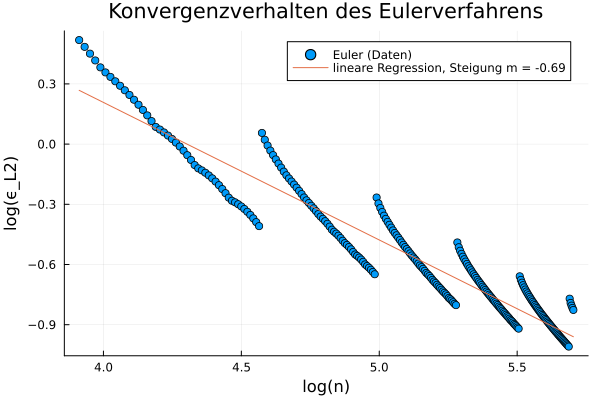

In [10]:
linreg(x, y) = hcat(fill!(similar(x), 1), x) \ y

log_n   = log.(collect(n_values))
log_eps = log.(ϵ_values)

n, m = linreg(log_n, log_eps)

plot(log_n, log_eps, seriestype=:scatter, label="Euler (Daten)",
     xlabel="log(n)", ylabel="log(ϵ_L2)", title="Konvergenzverhalten des Eulerverfahrens")
plot!(log_n, n .+ m .* log_n, label="lineare Regression, Steigung m = $(round(m, digits=2))", legend=:topright)


**Interpretation:** Die Steigung `m` der Ausgleichsgeraden im log-log-Plot entspricht der Konvergenzordnung des Verfahrens: $\epsilon_{L_2} \propto n^{m}$. Für das Eulerverfahren (Verfahren 1. Ordnung) erwarten wir $m \approx -1$, d.h. der Fehler fällt linear mit wachsendem $n$ (bzw. mit kleiner werdendem $dt = t_{max}/(n-1)$). Zum Vergleich zeigt das klassische Runge-Kutta-Verfahren (4. Ordnung) eine deutlich steilere Steigung von $m \approx -4$, da dessen lokaler Fehler pro Schritt $\mathcal{O}(dt^5)$ beträgt und sich über die Integration zu einem globalen Fehler $\mathcal{O}(dt^4)$ aufsummiert.

### Bonus: Konvergenzvergleich Euler vs. RK4
Zur Veranschaulichung des Unterschieds in der Konvergenzordnung plotten wir beide Fehlerkurven gemeinsam.

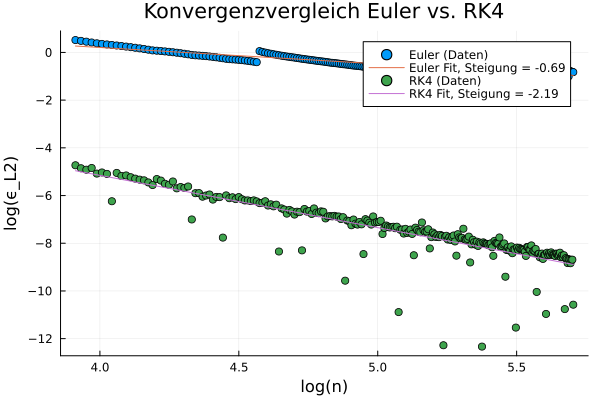

In [11]:
# Bonus: Vergleich der Konvergenz von Euler und RK4 im selben Plot
log_eps_rk4 = log.(ϵ_values_rk4)
n_rk4, m_rk4 = linreg(log_n, log_eps_rk4)

plot(log_n, log_eps, seriestype=:scatter, label="Euler (Daten)")
plot!(log_n, n .+ m .* log_n, label="Euler Fit, Steigung = $(round(m, digits=2))")
plot!(log_n, log_eps_rk4, seriestype=:scatter, label="RK4 (Daten)")
plot!(log_n, n_rk4 .+ m_rk4 .* log_n, label="RK4 Fit, Steigung = $(round(m_rk4, digits=2))",
      xlabel="log(n)", ylabel="log(ϵ_L2)", title="Konvergenzvergleich Euler vs. RK4", legend=:topright)
